# TV4 - Final Test Evaluation & Error Analysis

Notebook **chỉ đọc snapshot đã khóa** từ lần đánh giá Final Test duy nhất. Không gọi lại `model.predict(X_test)`.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
snapshot_path = PROJECT_ROOT / 'reports/evaluation/final_test_snapshot.json'
snapshot = json.loads(snapshot_path.read_text(encoding='utf-8'))
snapshot

{'schema_version': 1,
 'policy': 'locked final test evaluated once by TV4',
 'model': 'Logistic Regression + SMOTE',
 'labels': ['Negative', 'Neutral', 'Positive'],
 'metrics': {'test_count': 1683,
  'accuracy': 0.7373737373737373,
  'macro_f1': 0.57135314882083,
  'weighted_f1': 0.7488930544157996,
  'error_count': 442},
 'inference_seconds': 0.031002299998363014,
 'cv_macro_f1': 0.572705,
 'cv_to_final_gap': -0.0013518511791700272,
 'model_sha256': 'a6732e5970c4331fe8d1ab1ea16c00563a24dcb16ed070b39662d262457baaca',
 'split_sha256': 'e7fd70300538428fb4e5a26ef4d134d0dc307f6c64422e1089d020cf811bc0c7',
 'data_sha256': 'e8e13140ad607f0084a66cb2740c0b482a67d4b727d9cd15404e2ba3448ca8f9',
 'figure': 'reports/figures/tv4_final_test_confusion_matrix.png'}

## 1. Chỉ số Final Test và xếp hạng CV

In [2]:
metrics = pd.read_csv(PROJECT_ROOT / 'reports/evaluation/final_test_metrics.csv')
per_class = pd.read_csv(PROJECT_ROOT / 'reports/evaluation/final_test_per_class.csv')
ranking = pd.read_csv(PROJECT_ROOT / 'reports/evaluation/model_ranking_cv.csv')
display(metrics, per_class, ranking)

,test_count,accuracy,macro_f1,weighted_f1,error_count
0,1683,0.737374,0.571353,0.748893,442


,Label,Precision,Recall,F1,Support
0,Negative,0.331169,0.447368,0.380597,114
1,Neutral,0.446194,0.518293,0.479549,328
2,Positive,0.888502,0.821918,0.853914,1241


,Rank,Model,CV Macro F1 Mean,CV Macro F1 Std,Strategy,Best Params,Evaluation Set,Refit Time (s),Timing Scope
0,1,Logistic Regression,0.572705,0.010803,SMOTE,C=1.0,Development / Stratified 5-Fold CV,0.619840,1 refit / full Development set / local machine
1,2,Linear SVM,0.572392,0.025989,Balanced,C=0.1,Development / Stratified 5-Fold CV,0.072287,1 refit / full Development set / local machine
2,3,Random Forest,0.566381,0.013763,Balanced,"max_depth=30, n_estimators=400",Development / Stratified 5-Fold CV,1.533139,1 refit / full Development set / local machine
3,4,Stacking Ensemble,0.556037,0.023712,Mixed,cv=5,Development / Stratified 5-Fold CV,19.924297,1 refit / full Development set / local machine
4,5,Multinomial Naive Bayes,0.553418,0.018340,SMOTE,alpha=0.5,Development / Stratified 5-Fold CV,0.171911,1 refit / full Development set / local machine


## 2. Confusion Matrix và Normalized Confusion Matrix

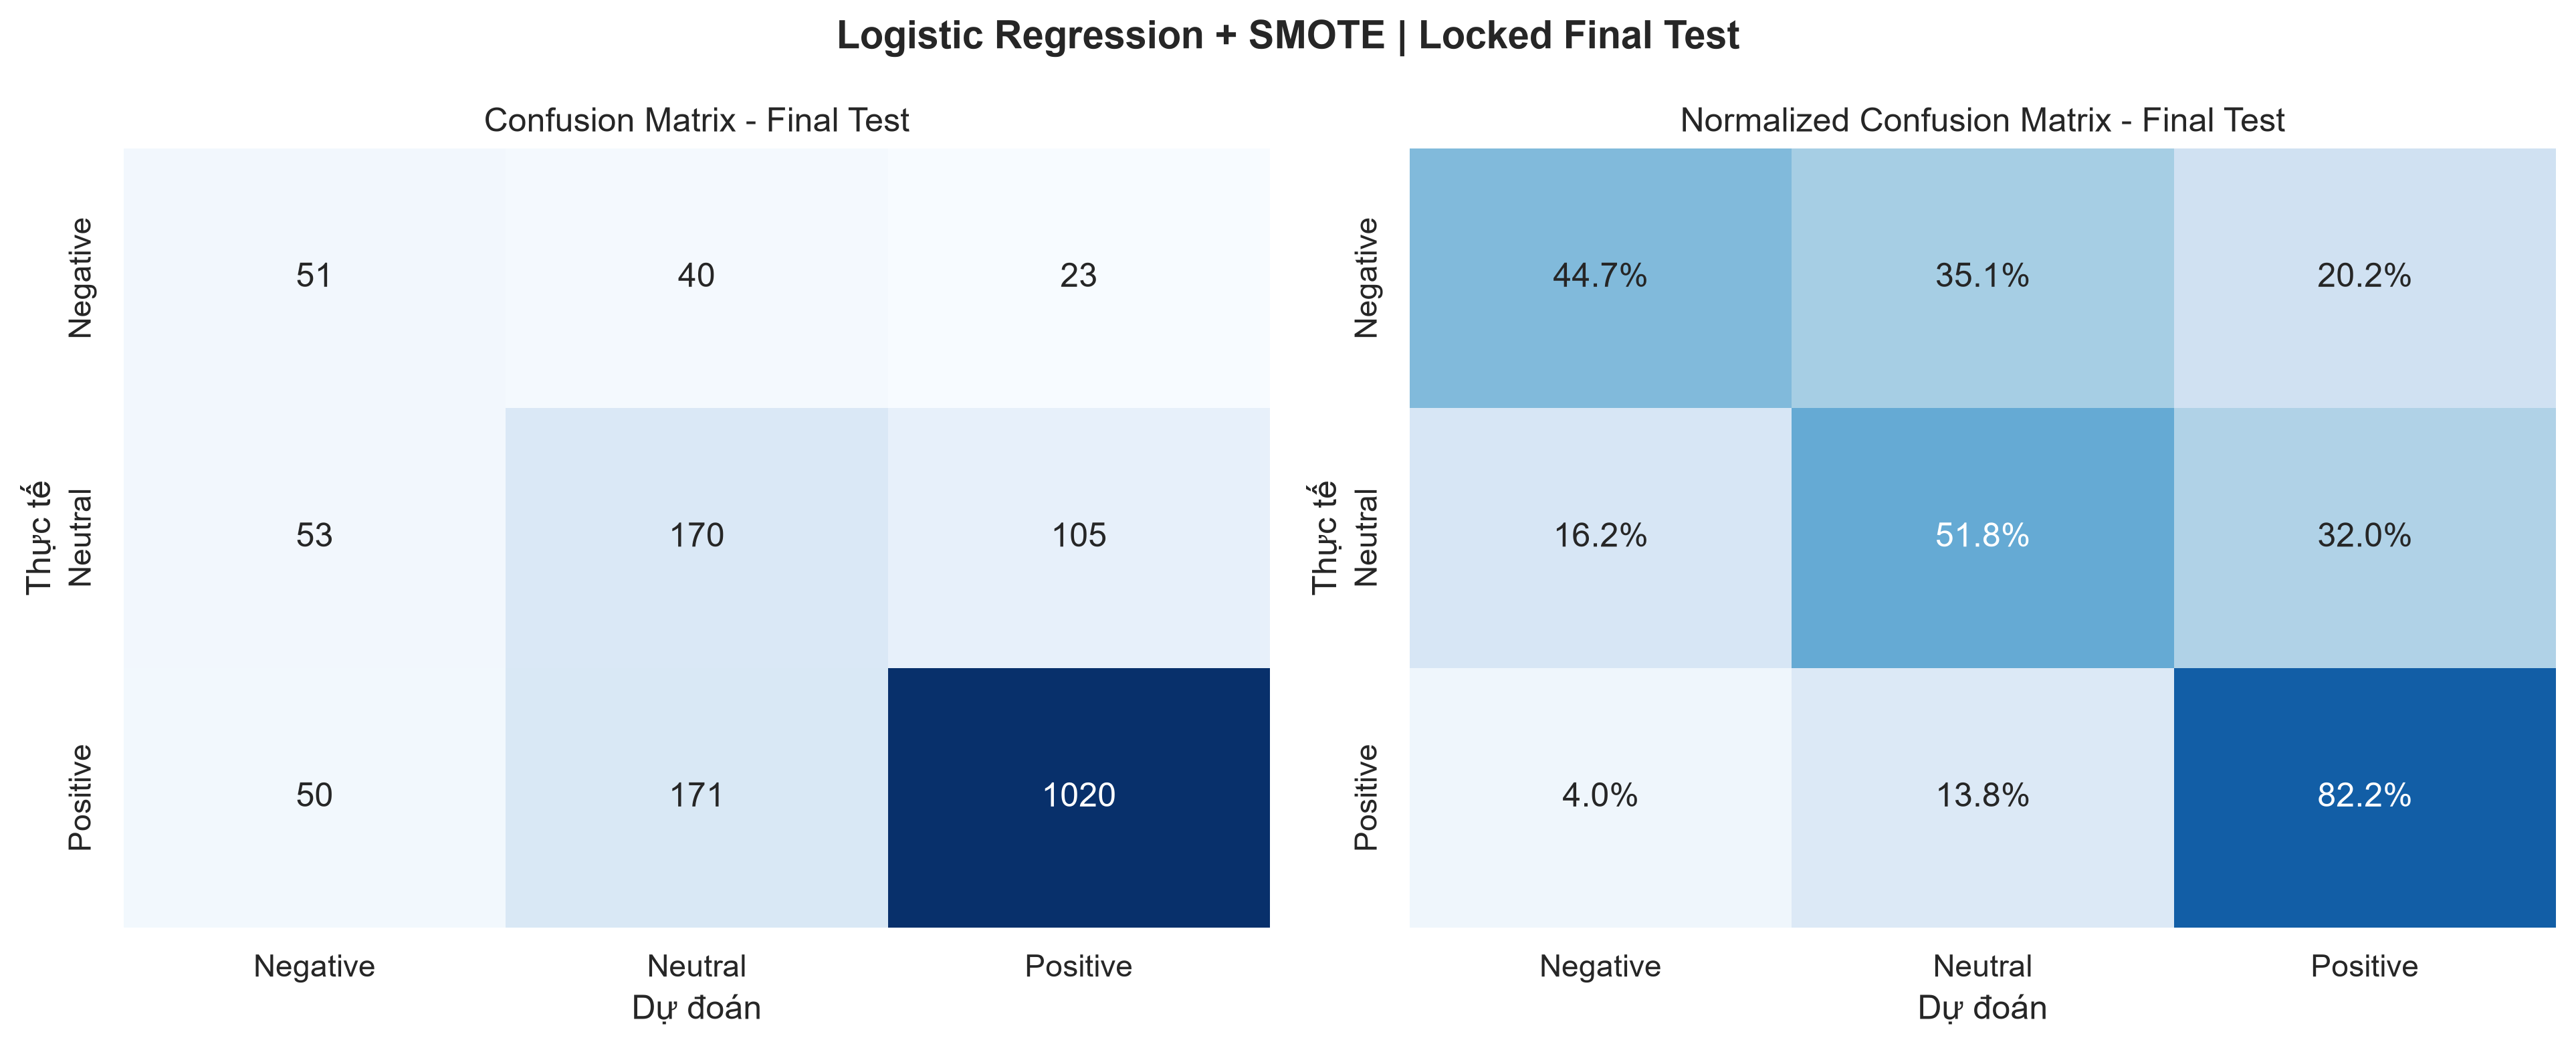

In [3]:
display(Image(filename=str(PROJECT_ROOT / 'reports/figures/tv4_final_test_confusion_matrix.png'), width=950))

## 3. Mười lăm mẫu lỗi đa dạng

In [4]:
errors = pd.read_csv(PROJECT_ROOT / 'reports/evaluation/error_analysis_15_samples.csv')
errors[['company', 'rating', 'actual', 'predicted', 'confidence', 'manual_category', 'manual_analysis', 'review']]

,company,rating,actual,predicted,confidence,manual_category,manual_analysis,review
0,FPT Software,3,Neutral,Positive,0.967481,Mixed sentiment,Nhiều tín hiệu tích cực ở đầu review lấn át ph...,Tốt cho người mới . Môi trường làm việc chuyên...
1,LG CNS Việt Nam,3,Neutral,Positive,0.962160,Label noise,Nội dung gần như hoàn toàn tích cực nhưng rati...,Working environment is very good!! . Công ty c...
2,VNG Corporation,3,Neutral,Positive,0.947038,Mixed sentiment,Khen môi trường nhưng nêu OT và chính sách khá...,"Môi trường năng động . Phòng tập gym, hoạt độn..."
3,TRUONG MINH THINH TECHNOLOGY JOINT STOCK COMPANY,4,Positive,Neutral,0.945215,Label noise,Rating 4 sao sinh Positive dù nội dung có nhiề...,"Sếp tốt, giờ giấc thoải mái . Thời gian làm vi..."
4,FPT Software,4,Positive,Neutral,0.944861,Mixed sentiment,Phần khen môi trường đi kèm chê lương và trang...,"Môi trường tốt, thời gian linh hoạt, đồng nghi..."
5,NashTech,3,Neutral,Negative,0.943666,Label noise,Nội dung tiêu cực rất mạnh nhưng rating 3 sao ...,Đội ngũ PM yếu kém và bao che khuyết điểm cho ...
6,"AZPLAYS Co., LTD",3,Neutral,Positive,0.934241,Mixed sentiment,"Nhiều ý khen phúc lợi, nhưng có bất tiện về kh...","Công ty ổn áp, chỉ làm xa nhà chứ mọi phúc lợi..."
7,FPT Software,4,Positive,Neutral,0.928102,Mixed sentiment,Khen cơ hội học hỏi nhưng chê lương thấp và tă...,Khá ổn để dấn thân vào ngành IT . môi trường n...
8,FPT Software,2,Negative,Positive,0.918792,Mixed sentiment,"Mở đầu tích cực, kết thúc bằng OT lặp lại, lươ...",Môi trường làm việc năng động . Môi trường năn...
9,FPT Software,2,Negative,Neutral,0.916357,Mixed sentiment,Câu khen môi trường chiếm nhiều token trước ph...,môi trường thoải mái thân thiện . Môi trường t...


## 4. Overfitting / Underfitting

Development CV Macro F1 = **0.5727**, Final Test Macro F1 = **0.5714**, chênh lệch = **-0.0014**. Khoảng cách rất nhỏ, chưa cho thấy overfitting nghiêm trọng. Lớp Negative vẫn khó nhất với Recall **44.74%** và F1 **0.3806**.

## Kết luận

Logistic Regression + SMOTE tổng quát hóa ổn định so với CV, nhưng dữ liệu mất cân bằng và weak label khiến Accuracy không đủ để đánh giá. Cần báo cáo Macro F1 và chỉ số từng lớp, đặc biệt là Negative.